# Diffusion Paper Recreation 1D Version
Recreating the 2D Diffusionmodedl from [HuggingFace](https://huggingface.co/blog/annotated-diffusion) as a 1D Version for electricity timeseries.


In [3]:
import math
from inspect import isfunction
from functools import partial

%matplotlib widget
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from einops import rearrange, reduce
from einops.layers.torch import Rearrange
import shutil
from pathlib import Path
import torch
from torch import nn, einsum
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from Ch_1_Data_Preparation.DataSplittingHelper import *
import numpy as np
import pandas as pd
from ema_pytorch import EMA

## Move and Prepare Data

In [2]:
manifest = pd.read_csv(r"../Ch_1_Data_Preparation/manifest.csv")
#manifest["sum_n_persons"] = manifest["n_persons"].apply(sum)

In [3]:
manifest

,Unnamed: 0,country,buildingType,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,...,capControl,occControl,comfortT_lb,comfortT_ub,cores,useCache,building_id,run_id,seed,sum_n_persons
0,0,DE,AB,Terraced,DE.02,1234.5,14,cold,False,4,...,True,False,21.0,24.0,1,False,0,run_000000,1000000,30
1,1,DE,AB,Terraced,DE.02,1234.5,14,cold,False,4,...,True,False,21.0,24.0,1,False,0,run_000001,1000001,30
2,2,DE,AB,Terraced,DE.02,1234.5,14,cold,False,4,...,True,False,21.0,24.0,1,False,0,run_000002,1000002,30
3,3,DE,AB,Terraced,DE.02,1722.3,20,hot,True,12,...,True,False,21.0,24.0,1,False,1,run_000003,1000003,36
4,4,DE,AB,Terraced,DE.02,1722.3,20,hot,True,12,...,True,False,21.0,24.0,1,False,1,run_000004,1000004,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14395,14395,DE,TH,Semi,DE.12,160.8,1,hot,False,12,...,True,False,21.0,24.0,1,False,4798,run_014395,1014395,4
14396,14396,DE,TH,Semi,DE.12,160.8,1,hot,False,12,...,True,False,21.0,24.0,1,False,4798,run_014396,1014396,4
14397,14397,DE,TH,Semi,DE.12,58.1,1,hot,False,14,...,True,False,21.0,24.0,1,False,4799,run_014397,1014397,1
14398,14398,DE,TH,Semi,DE.12,58.1,1,hot,False,14,...,True,False,21.0,24.0,1,False,4799,run_014398,1014398,1


In [4]:
strat_cols = ["buildingType", "buildingAgeBin"]
strat_cols_test = ["buildingType", "buildingAgeBin", "climateRegion","year_type","future"]
rest_cols = ['a_ref', 'sum_n_persons', 'n_apartments']
buildings, train_idx, val_idx, test_idx, train_buildings,val_buildings,test_buildings  ,train_df, val_df, test_df, holdout_buildings = split_manifests(manifest, strat_cols,holdout_type="TH", holdout_age="DE.05", fractions=[0.7, 0.15, 0.15])

buildings -> train 3276, val 702, test 702
rows-> train 9828, val 2106, test 2106


=== a_ref ===
       original    train      val     test
count   4680.00  3276.00   702.00   702.00
mean     478.18   479.06   480.61   471.65
std      514.32   513.48   526.77   506.24
min       20.10    21.20    20.10    20.50
25%      103.57   102.40   104.08   108.40
50%      199.90   199.60   199.05   207.45
75%      761.12   772.22   754.28   728.00
max     2246.10  2232.30  2191.80  2246.10

KS test (p < 0.05 suggests distributions differ):
train: stat=0.0057, p=1.0000
val: stat=0.0180, p=0.9869
test: stat=0.0219, p=0.9243

=== sum_n_persons ===
       original    train     val    test
count   4680.00  3276.00  702.00  702.00
mean       9.73     9.79    9.63    9.54
std       10.19    10.24   10.26    9.91
min        1.00     1.00    1.00    1.00
25%        2.00     2.00    2.00    2.00
50%        5.00     5.00    5.00    5.00
75%       15.00    15.00   14.00   15.00
max       47.00    47.00   45.00   47.00

KS test (p < 0.05 suggests distributions differ):
train: stat=0.0059, p

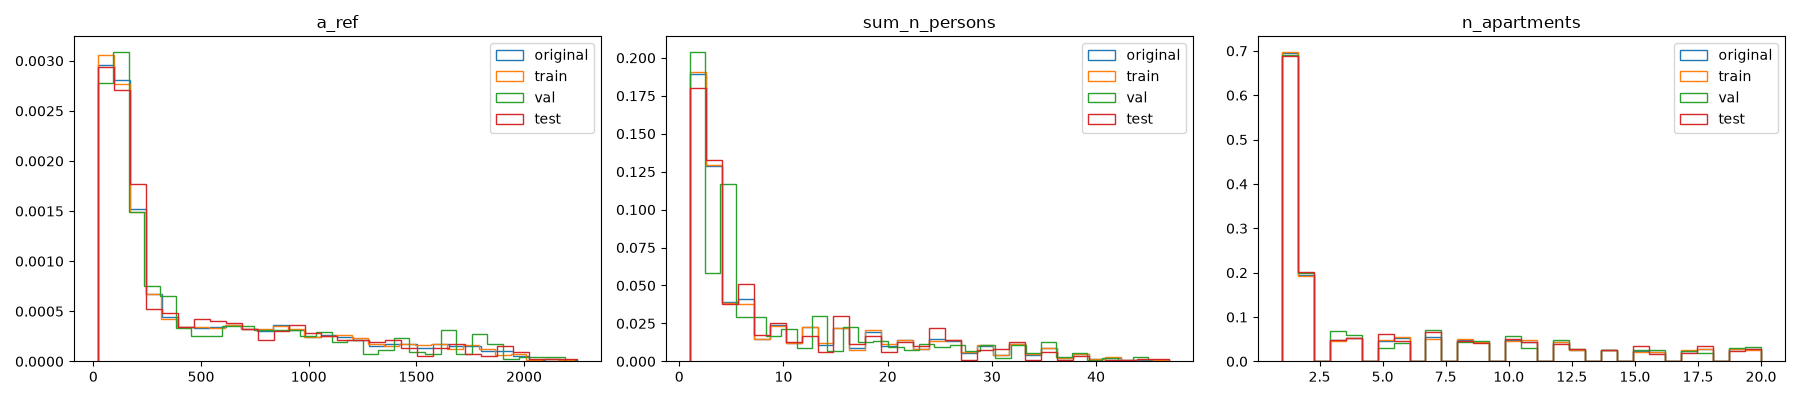

In [5]:
check_distr(buildings, train_buildings, val_buildings, test_buildings, strat_cols_test, rest_cols)

In [6]:
source_dir = Path(r"../Ch_1_Data_Preparation/Generation/Generation")
target_root = Path(r"../DataSplit/Data")

split_dirs = {
    "train": target_root/"train",
    "val": target_root/"val",
    "test": target_root/"test",
    "holdout_test": target_root/"test"/"holdout",
}

move_split_data(manifest, source_dir,split_dirs, train_buildings, val_buildings, test_buildings, holdout_buildings)

  0%|          | 0/14400 [00:00<?, ?it/s]

Copied: 303
Missing: 14097


### Dataset and Dataloader

In [7]:
ALL_COLS = [
    "T",
    "Occupancy Home Active",
    "Occupancy Home Not Active",
    "Electricity Load",
    "Hot Water Load",
    "Heating Load",
]

TS_AGG = {
    "T": "first",
    "Occupancy Home Active": "first",
    "Occupancy Home Not Active": "first",
    "Electricity Load": "mean",
    "Hot Water Load": "mean",
    "Heating Load": "mean",
}

TARGET_COLS = ["Electricity Load", "Hot Water Load"] #"T", "Occupancy Home Not Active", "Occupancy Home Not Active","Heating Load", "Electricity Load", "Hot Water Load"

DYNAMIC_COND_COLS = ["Occupancy Home Active", "Occupancy Home Not Active"] #"T", "Occupancy Home Active", "Occupancy Home Not Active"
N_DY_CON_COLS = len(DYNAMIC_COND_COLS)
STATIC_CAT_COLS = ["buildingType"]
#"buildingType","buildingAgeBin","year_type","climateRegion"
STATIC_BOOL_COLS = ["future"] #"future"

STATIC_CONT_COLS = ["sum_n_persons"] #"a_ref","n_apartments","sum_n_persons"


train_df_exist, train_idx_missing = existing_filter(train_df, split_dirs["train"])
val_df_exist, val_idx_missing = existing_filter(val_df, split_dirs["val"])
test_df_exist, test_idx_missing = existing_filter(test_df, split_dirs["test"])

preprocessor = PreprocessStaticCols(static_cat_cols=STATIC_CAT_COLS,static_cont_cols=STATIC_CONT_COLS, static_bool_cols=STATIC_BOOL_COLS).fit(train_df_exist)

cat_cardinalities = [len(cats) for cats in preprocessor.cat_encoder.categories_]
n_cont = len(preprocessor.static_cont_cols)
n_bool = len(preprocessor.static_bool_cols)

train_files, train_run_ids, train_static = normalizestatic(train_df_exist,split_dirs["train"],preprocessor)
val_files, val_run_ids, val_static = normalizestatic(val_df_exist,split_dirs["val"],preprocessor)
test_files, test_run_ids, test_static = normalizestatic(test_df_exist,split_dirs["test"],preprocessor)

WINDOW_DAYS = 1
STRIDE_DAYS = 1
RESOLUTION = "1min"

STEPS_PER_DAY = stepsperday(RESOLUTION)

WINDOW_LENGTH = WINDOW_DAYS * STEPS_PER_DAY
STRIDE = STRIDE_DAYS * STEPS_PER_DAY

Missing Files: 9633
Existing Files: 195
Total: 9828
Missing Files: 2052
Existing Files: 54
Total: 2106
Missing Files: 2052
Existing Files: 54
Total: 2106


In [8]:
for col, categories in zip(
    STATIC_CAT_COLS,
    preprocessor.cat_encoder.categories_
):
    print(col)
    print({category: i for i, category in enumerate(categories)})

buildingType
{'SFH': 0}


In [9]:
means, stds = calc_mean_std(train_files,ALL_COLS,resolution=None, aggregation=TS_AGG)
save_stats("stats_1min.npz", cols=ALL_COLS, res=None, mean=means, std=stds)
stats = load_stats("stats_1min.npz")
target_mean, target_std = select_stats(stats, TARGET_COLS, zero_cols=["Hot Water Load"])
condition_mean, condition_std = select_stats(stats, DYNAMIC_COND_COLS)

  0%|          | 0/195 [00:00<?, ?it/s]

In [10]:
condition_mean

tensor([[0.7984],
        [0.7814]])

In [11]:
class AwayFeature:
    def __init__(self, condition_mean, condition_std):
        self.mean = torch.as_tensor(condition_mean).float().cpu().view(1, -1, 1)
        self.std  = torch.as_tensor(condition_std).float().cpu().view(1, -1, 1)

    def __call__(self, dyn):                       # dyn: [B, n_dyn, L], z-scored
        mean, std = self.mean.to(dyn.device), self.std.to(dyn.device)
        raw = dyn * std + mean                     # back to person counts
        away = (raw.sum(dim=1, keepdim=True) < 0.5).to(dyn.dtype)
        return torch.cat([dyn, away], dim=1)       # [B, n_dyn + 1, L]

prep_dyn = AwayFeature(condition_mean, condition_std)
N_DYN_MODEL = len(DYNAMIC_COND_COLS) + 1

In [12]:
# create dataset
train_dataset = h5Dataset(
    files=train_files,
    rund_ids=train_run_ids,
    gen_cols=TARGET_COLS,
    cond_cols=DYNAMIC_COND_COLS,
    window_length=WINDOW_LENGTH,
    stride=STRIDE,
    target_mean=target_mean,
    target_std=target_std,
    condition_mean=condition_mean,
    condition_std=condition_std,
    static_by_run_id=train_static,
    resolution=RESOLUTION,
    shufflefiles=True,
    shufflewindows=True,
    buffer_size=4096,
    aggregation=TS_AGG
)

val_dataset = h5Dataset(
    files=val_files,
    rund_ids=val_run_ids,
    gen_cols=TARGET_COLS,
    cond_cols=DYNAMIC_COND_COLS,
    window_length=WINDOW_LENGTH,
    stride=STRIDE,
    target_mean=target_mean,
    target_std=target_std,
    condition_mean=condition_mean,
    condition_std=condition_std,
    static_by_run_id=val_static,
    resolution=RESOLUTION,
    shufflefiles=True,
    shufflewindows=True,
    buffer_size=4096,
    aggregation=TS_AGG
)

In [13]:
# dataloader

BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    drop_last=True,
    multiprocessing_context="spawn",
    timeout=30
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    drop_last=True,
    multiprocessing_context="spawn",
    timeout=30
)

### Helperfunctions

In [14]:
def exists(x):
    return x is not None

def default(val, d):
    if exists(val):
        return val
    return d() if isfunction(d) else d


def num_to_groups(num, divisor):
    groups = num // divisor
    remainder = num % divisor
    arr = [divisor] * groups
    if remainder > 0:
        arr.append(remainder)
    return arr


class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x


def Downsample1d(dim, dim_out=None):
    return nn.Conv1d(
        dim,
        default(dim_out, dim),
        kernel_size=4,
        stride=2,
        padding=1
    )


def Upsample1d(dim, dim_out=None):
    return nn.Sequential(
        nn.Upsample(scale_factor=2, mode="nearest"),
        nn.Conv1d(dim,  default(dim_out, dim), kernel_size=3, padding=1)
    )


In [15]:
layer = Downsample1d(dim=1, dim_out=2)
x = torch.randn(1,1,10)
y = layer(x)

In [16]:
x

tensor([[[-1.8019, -0.2889,  1.1362, -0.8451, -0.9800, -0.9536,  1.4481,
           0.7346,  0.4432, -0.1706]]])

In [17]:
y

tensor([[[-0.2701, -0.7011, -1.1083, -1.1495, -0.2136],
         [ 0.8629, -0.8397,  0.9273,  0.7949, -0.3976]]],
       grad_fn=<ConvolutionBackward0>)

In [18]:
x.shape, y.shape

(torch.Size([1, 1, 10]), torch.Size([1, 2, 5]))

In [19]:
layerup = Upsample1d(2,1)
yup = layerup(y)

In [20]:
y.shape, yup.shape

(torch.Size([1, 2, 5]), torch.Size([1, 1, 10]))

In [21]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


In [22]:
class StaticConditionEmbedder(nn.Module):
    def __init__(self, cat_cardinalities, n_cont, n_bool, cond_dim, out_dim):
        super().__init__()
        # one Embedding per categorical column (buildingType, buildingAgeBin, ...)
        self.cat_embeds = nn.ModuleList([
            nn.Embedding(card + 1, cond_dim) for card in cat_cardinalities  # +1 for the OrdinalEncoder's unknown/pad index
        ])
        in_dim = len(cat_cardinalities) * cond_dim + n_cont + n_bool
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, out_dim), nn.SiLU(), nn.Linear(out_dim, out_dim)
        )

    def forward(self, static_cat, static_cont, static_bool):
        cat_parts = [emb(static_cat[:, i]) for i, emb in enumerate(self.cat_embeds)]
        c = torch.cat(cat_parts + [static_cont, static_bool], dim=-1)
        return self.mlp(c)

In [23]:
test = SinusoidalPositionEmbeddings(8)
test(torch.tensor([10, 100, 500,1000]))

tensor([[-0.5440,  0.4477,  0.0215,  0.0010, -0.8391,  0.8942,  0.9998,  1.0000],
        [-0.5064, -0.9975,  0.2138,  0.0100,  0.8623, -0.0707,  0.9769,  0.9999],
        [-0.4678, -0.9380,  0.8806,  0.0500, -0.8838, -0.3467,  0.4738,  0.9988],
        [ 0.8269,  0.6503,  0.8345,  0.0998,  0.5624, -0.7597, -0.5511,  0.9950]])

In [24]:
# weight shape (out_channels, in_channels / groups, kernel_size)
class WeightStandardizedConv1d(nn.Conv1d):
    def forward(self,x):
        eps = 1e-5 if x.dtype == torch.float32 else 1e-3
        weight = self.weight
        mean = reduce(weight, "o ... -> o 1 1 ", "mean")
        var = reduce(weight, "o ... -> o 1 1 ", partial(torch.var, unbiased=False))
        normalized_weight = (weight - mean) * (var + eps).rsqrt()

        return F.conv1d(
            x,
            normalized_weight,
            self.bias,
            self.stride,
            self.padding,
            self.dilation,
            self.groups,
        )

In [25]:
test = torch.rand((3,3,3))
print(test.shape)
test_red = reduce(test, "o i ... -> o 1 1 ", "mean")
print(test_red.shape)

torch.Size([3, 3, 3])
torch.Size([3, 1, 1])


In [26]:
conv = WeightStandardizedConv1d(
    in_channels=3,
    out_channels=3,
    kernel_size=3,
    padding=1
)

# Batch size = 1
# Channels = 2
# Sequence length = 8
x = torch.randn(1, 3, 8)

print("Input shape:", x.shape)

y = conv(x)

print("\nOutput shape:", y.shape)
print("\nOutput:")
print(y)

Input shape: torch.Size([1, 3, 8])

Output shape: torch.Size([1, 3, 8])

Output:
tensor([[[ 1.4085, -1.3610, -1.6407, -2.0911, -0.9385, -1.0110, -1.5597,
           6.8858],
         [ 1.1508, -2.6228,  1.5683, -1.5865,  1.1101,  2.8046, -2.3286,
           3.2404],
         [ 0.1930,  0.9712, -0.9415, -1.1881, -4.3753, -4.0787, -4.5108,
          -2.5137]]], grad_fn=<ConvolutionBackward0>)


In [27]:

class Block1d(nn.Module):
    def __init__(self, dim, dim_out, groups=8):
        super().__init__()
        self.proj = WeightStandardizedConv1d(dim, dim_out, 3, padding=1)
        self.norm = nn.GroupNorm(groups, dim_out)
        self.act = nn.SiLU()

    def forward(self, x, scale_shift=None):
        x = self.proj(x)
        x = self.norm(x)

        if exists(scale_shift):
            scale, shift = scale_shift
            x = x * (scale + 1) + shift

        x = self.act(x)
        return x


In [28]:
class ResnetBlock1d(nn.Module):
    def __init__(self,dim,dim_out,*,time_emb_dim=None,groups=8):
        super().__init__()

        self.mlp = (
            nn.Sequential(nn.SiLU(),nn.Linear(time_emb_dim, dim_out * 2))
            if exists(time_emb_dim)
            else None
        )

        self.block1 = Block1d(dim,dim_out,groups=groups)

        self.block2 = Block1d(dim_out,dim_out,groups=groups)

        self.res_conv = (nn.Conv1d(dim, dim_out, 1) if dim != dim_out else nn.Identity())

    def forward(self, x, time_emb=None):

        scale_shift = None
        if exists(self.mlp) and exists(time_emb):
            time_emb = self.mlp(time_emb)

            # IMPORTANT CHANGE:
            # [B,C] -> [B,C,1]
            time_emb = rearrange(time_emb,"b c -> b c 1")

            scale_shift = time_emb.chunk(2,dim=1)

        h = self.block1(x,scale_shift=scale_shift)
        h = self.block2(h)
        return h + self.res_conv(x)

In [29]:
class Attention1d(nn.Module):
    def __init__(self,dim,heads=4,dim_head=32):
        super().__init__()
        self.scale = dim_head ** -0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv1d(dim,hidden_dim * 3,1,bias=False)

        self.to_out = nn.Conv1d(hidden_dim,dim,1)

    def forward(self, x):
        qkv = self.to_qkv(x).chunk(3,dim=1)

        q, k, v = map(lambda t: rearrange(t,"b (h d) n -> b h d n",h=self.heads),qkv)

        q = q * self.scale

        sim = torch.einsum("b h d i, b h d j -> b h i j",q,k)

        sim = sim - sim.amax(dim=-1,keepdim=True).detach()

        attn = sim.softmax(dim=-1)

        out = torch.einsum("b h i j, b h d j -> b h i d",attn,v)

        out = rearrange(out,"b h n d -> b (h d) n")
        return self.to_out(out)

class LinearAttention1D(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head**-0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv1d(dim, hidden_dim * 3, 1, bias=False)

        self.to_out = nn.Sequential(nn.Conv1d(hidden_dim, dim, 1),
                                    nn.GroupNorm(1, dim))

    def forward(self, x):
        #b, c, n = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(lambda t: rearrange(t, "b (h c) n -> b h c n", h=self.heads), qkv)

        q = q.softmax(dim=-2)
        k = k.softmax(dim=-1)

        q = q * self.scale
        context = torch.einsum("b h d n, b h e n -> b h d e", k, v)

        out = torch.einsum("b h d e, b h d n -> b h e n", context, q)
        out = rearrange(out, "b h c n -> b (h c) n", h=self.heads)
        return self.to_out(out)


In [30]:
class PreNorm1d(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()

        self.fn = fn
        self.norm = nn.GroupNorm(1, dim)

    def forward(self, x):
        return self.fn(
            self.norm(x)
        )

In [31]:
class Unet1D(nn.Module):
    def __init__(
        self,
        dim=32,
        channels=1,
        dim_mults=(1, 2, 4),
        resnet_block_groups=8,
        cat_cardinalities=None,
        n_cont=0,
        n_bool=0,
        n_dyn_con_cols = 0,

    ):
        super().__init__()

        self.channels = channels
        self.n_dyn_con_cols = n_dyn_con_cols

        self.init_conv = nn.Conv1d(channels +2 + n_dyn_con_cols, dim,kernel_size=3, padding=1) #+2 because extra sin/cos

        dims = [dim, *map(lambda m: dim * m, dim_mults)]
        in_out = list(zip(dims[:-1], dims[1:]))

        block_klass = partial(ResnetBlock1d,groups=resnet_block_groups) #partial constructor for resnet block

        time_dim = dim * 4 #design convention: widening of conditioning dims

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(dim),
            nn.Linear(dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        self.cond_embedder = StaticConditionEmbedder(
        cat_cardinalities=cat_cardinalities,
        n_cont=n_cont,
        n_bool=n_bool,
        cond_dim=16, #todo make constructor argument
        out_dim=time_dim,
    )

        # down path
        self.downs = nn.ModuleList([])

        for dim_in, dim_out in in_out:
            self.downs.append(nn.ModuleList([block_klass(dim_in,dim_in,time_emb_dim=time_dim), Downsample1d(dim_in,dim_out)]))

        # Bottleneck
        mid_dim = dims[-1]

        self.mid_block1 = block_klass(mid_dim,mid_dim,time_emb_dim=time_dim)
        self.mid_attn = Residual(PreNorm1d(mid_dim,Attention1d(mid_dim)))
        self.mid_block2 = block_klass(mid_dim,mid_dim,time_emb_dim=time_dim)


        # Up path
        self.ups = nn.ModuleList([])
        for dim_in, dim_out in reversed(in_out):

            self.ups.append(nn.ModuleList([Upsample1d(dim_out,dim_in),block_klass(dim_in * 2,dim_in,time_emb_dim=time_dim)])) #dim_in * 2 cause cat with skip cons


        # Final output
        self.final_block = block_klass(dim,dim,time_emb_dim=time_dim)
        self.final_conv = nn.Conv1d(dim,channels,kernel_size=1)

    def forward(self, x, time, static_cat, static_cont, static_bool, dyn=None):

        b, c, length = x.shape

        positions = torch.arange(length,device=x.device,dtype=x.dtype)

        time_sin = torch.sin(2 * math.pi * positions / 1440)
        time_cos = torch.cos(2 * math.pi * positions / 1440)

        time_sin = time_sin[None, None, :].expand(b, 1, length)
        time_cos = time_cos[None, None, :].expand(b, 1, length)

        parts= [x]
        if self.n_dyn_con_cols >0:
            parts.append(dyn)
        parts += [time_sin, time_cos]    # Todo put time directily in x
        x = torch.cat(parts,dim=1)

        x = self.init_conv(x)

        t = self.time_mlp(time) + self.cond_embedder(static_cat, static_cont, static_bool)

        skips = []
        # DownPath
        for block, downsample in self.downs:

            x = block(x, t)
            skips.append(x)
            x = downsample(x)

        # Bottleneck
        x = self.mid_block1(x, t)
        x = self.mid_attn(x)
        x = self.mid_block2(x, t)

        # Up path
        for upsample, block in self.ups:
            x = upsample(x)
            skip = skips.pop()

            if x.shape[-1] != skip.shape[-1]:
                x = F.interpolate(x, size=skip.shape[-1], mode="nearest")

            x = torch.cat((x, skip),dim=1)
            x = block(x, t)

        # Final
        x = self.final_block(x, t)
        return self.final_conv(x)

In [32]:
def cosine_beta_schedule(timesteps, s=0.008):
    """
    cosine schedule as proposed in https://arxiv.org/abs/2102.09672
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

def quadratic_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

def sigmoid_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    betas = torch.linspace(-6, 6, timesteps)
    return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start


In [33]:
timesteps = 1000

# define beta schedule
betas = sigmoid_beta_schedule(timesteps=timesteps)

# define alphas
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

posterior_mean_coef1 = betas * torch.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod)
posterior_mean_coef2 = (1. - alphas_cumprod_prev) * torch.sqrt(alphas) / (1. - alphas_cumprod)
sqrt_recip_alphas_cumprod = torch.sqrt(1. / alphas_cumprod)
sqrt_recipm1_alphas_cumprod = torch.sqrt(1. / alphas_cumprod - 1.)

# calculations for diffusion q(x_t | x_{t-1}) and others
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

# calculations for posterior q(x_{t-1} | x_t, x_0)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)


### Forward Diffusion Process

In [34]:
# forward diffusion (using the nice property)
def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_alphas_cumprod_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod, t, x_start.shape
    )

    return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise


### Loss Function

In [35]:
def p_losses(denoise_model, x_start, t, static_cat, static_cont, static_bool, noise=None, dyn=None, loss_type="l1"):
    if noise is None:
        noise = torch.randn_like(x_start)

    x_noisy = q_sample(x_start=x_start, t=t, noise=noise)

    drop_mask = torch.rand(x_start.shape[0], device=x_start.device) < 0.0
    static_cat = static_cat.clone()
    static_cont = static_cont.clone()
    static_bool = static_bool.clone()
    static_cat[drop_mask] = 0          # index 0 ie unknown
    static_cont[drop_mask] = 0.0
    static_bool[drop_mask] = 0.0


    predicted_noise = denoise_model(x_noisy, t, static_cat, static_cont, static_bool, dyn) # ToDO adapt for CFG

    if loss_type == 'l1':
        loss = F.l1_loss(noise, predicted_noise)
    elif loss_type == 'l2':
        loss = F.mse_loss(noise, predicted_noise)
    elif loss_type == "huber":
        loss = F.smooth_l1_loss(noise, predicted_noise)
    else:
        raise NotImplementedError()

    return loss


### Define Dataset and Dataloader

### Sampling

In [36]:
# @torch.inference_mode()
# def p_sample(model, x, t, t_index):
#     betas_t = extract(betas, t, x.shape)
#     sqrt_one_minus_alphas_cumprod_t = extract(
#         sqrt_one_minus_alphas_cumprod, t, x.shape
#     )
#     sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)
#
#     # Equation 11 in the paper
#     # Use our model (noise predictor) to predict the mean
#     model_mean = sqrt_recip_alphas_t * (
#         x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t
#     )
#
#     if t_index == 0:
#         return model_mean
#     else:
#         posterior_variance_t = extract(posterior_variance, t, x.shape)
#         noise = torch.randn_like(x)
#         # Algorithm 2 line 4:
#         return model_mean + torch.sqrt(posterior_variance_t) * noise
#
# # Algorithm 2 (including returning all images)
# @torch.inference_mode()
# def p_sample_loop(model, shape):
#     device = next(model.parameters()).device
#
#     b = shape[0]
#     # start from pure noise (for each example in the batch)
#     img = torch.randn(shape, device=device)
#     imgs = []
#
#     for i in tqdm(reversed(range(0, timesteps)), desc='sampling loop time step', total=timesteps):
#         img = p_sample(model, img, torch.full((b,), i, device=device, dtype=torch.long), i)
#         imgs.append(img.cpu().numpy())
#     return imgs
#
# @torch.inference_mode()
# def sample(model, image_size, batch_size=16, channels=3):
#     return p_sample_loop(model, shape=(batch_size, channels, image_size, image_size))
#
# @torch.inference_mode()
# def sample1d(model, sequence_length=96, batch_size=16, channels=1):
#     return p_sample_loop(model, shape=(batch_size, channels, sequence_length))

# @torch.inference_mode()
# def p_sample(model, x, t, t_index, static_cat, static_cont, static_bool):
#     betas_t = extract(betas, t, x.shape)
#     sqrt_one_minus_alphas_cumprod_t = extract(sqrt_one_minus_alphas_cumprod, t, x.shape)
#     sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)
#
#     pred_noise = model(x, t, static_cat, static_cont, static_bool)
#
#     model_mean = sqrt_recip_alphas_t * (
#         x - betas_t * pred_noise / sqrt_one_minus_alphas_cumprod_t
#     )
#
#     if t_index == 0:
#         return model_mean
#     else:
#         posterior_variance_t = extract(posterior_variance, t, x.shape)
#         noise = torch.randn_like(x)
#         return model_mean + torch.sqrt(posterior_variance_t) * noise
#
# lo, hi = float("inf"), float("-inf")
# for batch in train_dataloader:          # one epoch, no grad needed
#     x = batch["target"]
#     lo = min(lo, x.min().item())
#     hi = max(hi, x.max().item())
# print(lo, hi)
lo = torch.full((len(TARGET_COLS),), float("inf"))
hi = torch.full((len(TARGET_COLS),), float("-inf"))

for batch in train_dataloader:
    x = batch["target"]
    lo = torch.minimum(lo, x.amin(dim=(0, 2)))
    hi = torch.maximum(hi, x.amax(dim=(0, 2)))

X0_MIN = lo.view(1, -1, 1)
X0_MAX = hi.view(1, -1, 1)

@torch.inference_mode()
def p_sample(model, x, t, t_index,static_cat, static_cont, static_bool, dyn=None,clip_denoised=True):
    pred_noise = model(x, t, static_cat, static_cont, static_bool, dyn)

    # predict x0 from x_t and the predicted noise
    x0 = (extract(sqrt_recip_alphas_cumprod, t, x.shape) * x
          - extract(sqrt_recipm1_alphas_cumprod, t, x.shape) * pred_noise)
    if clip_denoised:
        x0 = torch.clamp(x0, X0_MIN.to(x.device), X0_MAX.to(x.device))

    # posterior mean q(x_{t-1} | x_t, x0)
    model_mean = (extract(posterior_mean_coef1, t, x.shape) * x0
                  + extract(posterior_mean_coef2, t, x.shape) * x)

    if t_index == 0:
        return model_mean
    noise = torch.randn_like(x)
    return model_mean + torch.sqrt(extract(posterior_variance, t, x.shape)) * noise

@torch.inference_mode()
def p_sample_loop(model, shape, static_cat, static_cont, static_bool, dyn=None): # toDo rename image variable since its 1D now
    device = next(model.parameters()).device
    b = shape[0]
    img = torch.randn(shape, device=device)
    imgs = []

    for i in tqdm(reversed(range(0, timesteps)), desc='sampling loop time step', total=timesteps):
        t = torch.full((b,), i, device=device, dtype=torch.long)
        img = p_sample(model, img, t, i, static_cat, static_cont, static_bool, dyn)
        imgs.append(img.cpu().numpy())
    return imgs


@torch.inference_mode()
def sample1d(model, sequence_length, batch_size, channels, static_cat, static_cont, static_bool, dyn=None):
    return p_sample_loop(
        model,
        shape=(batch_size, channels, sequence_length),
        static_cat=static_cat,
        static_cont=static_cont,
        static_bool=static_bool,
        dyn= dyn
    )


In [37]:
X0_MIN, X0_MAX

(tensor([[[-0.5670],
          [ 0.0000]]]),
 tensor([[[23.3737],
          [34.0250]]]))

### Train the Model

In [38]:
from pathlib import Path

def num_to_groups(num, divisor):
    groups = num // divisor
    remainder = num % divisor
    arr = [divisor] * groups
    if remainder > 0:
        arr.append(remainder)
    return arr

results_folder = Path("./results")
results_folder.mkdir(exist_ok = True)
save_and_sample_every = 1000


In [39]:
from torch.optim import Adam

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Unet1D(
    dim=64,
    channels=2,
    dim_mults=(1, 2, 4),
    cat_cardinalities=cat_cardinalities,
    n_cont=n_cont,
    n_bool=n_bool,
    n_dyn_con_cols=N_DY_CON_COLS
).to(device)

optimizer = Adam(model.parameters(), lr=1e-4)

ema = EMA(
    model,
    beta=0.999,              # decay
    update_after_step=100,   # don't start averaging until then
    update_every=1,
    power=2/3,               # only used with inv_gamma warmup (see below)
)


## Logging with WandB

In [61]:
import wandb

wandb.login()

run = wandb.init(
    project="diffusion-model",
    config={
        "epochs": 1,
        "timesteps": timesteps,
        "loss_type": "huber",
        "learning_rate": optimizer.param_groups[0]["lr"],
        "schedule": "sigmoid_beta"
    }
)

In [62]:
#model.load_state_dict(torch.load("model.pth"))

In [63]:
epochs = 20
global_step = 0
for epoch in tqdm(range(epochs)):

    model.train()

    running_loss = 0
    num_batches = 0

    for step, batch in enumerate(train_dataloader):
        x = batch["target"].to(device)
        dyn = batch["condition"].to(device)
        static_cat = batch["static_cat"].to(device)
        static_cont = batch["static_cont"].to(device)
        static_bool = batch["static_bool"].to(device)

        optimizer.zero_grad()

        t = torch.randint(0, timesteps, (x.shape[0],), device=device).long()

        loss = p_losses(
            model, x, t, static_cat, static_cont, static_bool, dyn=dyn,
            loss_type="huber",
        )

        loss.backward()
        optimizer.step()
        ema.update()

        if step % 100 == 0:
            print("Loss:", loss.item())

        running_loss += loss.item()
        num_batches += 1

        run.log({
            "train/loss": loss.item(),
            "train/learning_rate": optimizer.param_groups[0]["lr"],
            "epoch": epoch + 1,
            "global_step": global_step,
        })

        global_step += 1

    epoch_loss = running_loss / num_batches

    print(
        f"Epoch {epoch + 1}: "
        f"loss={epoch_loss:.4f}"
    )

    run.log({
        "epoch/loss": epoch_loss,
        "epoch": epoch + 1,
    })

run.finish()

  0%|          | 0/20 [00:00<?, ?it/s]

Loss: 0.013924983330070972
Loss: 0.010821404866874218
Loss: 0.011788329109549522
Loss: 0.012851875275373459
Loss: 0.01736127957701683
Loss: 0.018662646412849426
Loss: 0.016413524746894836
Loss: 0.020882876589894295
Loss: 0.023493802174925804
Loss: 0.019864866510033607
Loss: 0.018760284408926964
Loss: 0.020236942917108536
Loss: 0.01857675239443779
Loss: 0.02002367191016674
Loss: 0.017935357987880707
Loss: 0.02087968774139881
Loss: 0.013685496523976326
Loss: 0.010086329653859138
Loss: 0.01847347430884838
Loss: 0.013202071189880371
Loss: 0.019147634506225586
Loss: 0.015412294305860996
Loss: 0.017573075369000435
Epoch 1: loss=0.0170
Loss: 0.018104519695043564
Loss: 0.016266725957393646
Loss: 0.01158069260418415
Loss: 0.01658768765628338
Loss: 0.01563064195215702
Loss: 0.012077126652002335
Loss: 0.01183675043284893
Loss: 0.0152214877307415
Loss: 0.01499856635928154
Loss: 0.019178595393896103
Loss: 0.011990249156951904
Loss: 0.014932575635612011
Loss: 0.014396264217793941
Loss: 0.02108075469

epoch,▁▁▂▂▂▂▂▂▂▂▂▃▃▃▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇███████
epoch/loss,█▆▅▅▄▄▃▃▂▂▂▁▂▂▁▁▁▁▁▁
global_step,▁▁▁▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇███
train/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,▃▅▃▄█▃▂▅▄▃▅▄▃▁▅▄▆▃▄▄▃▂▃▄▂▅▇▂▄▃▄▅▄▅▅▂▃▂▃▃
epoch,20
epoch/loss,0.01382
global_step,44419
train/learning_rate,0.0001
train/loss,0.01685


In [74]:
torch.save(ema.ema_model.state_dict(), "model_DHW_elec_occ_cond_ema.pth")

In [43]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total:     {total:,}")
print(f"Trainable: {trainable:,}")
print(f"Frozen:    {total - trainable:,}")

Total:     2,397,218
Trainable: 2,397,218
Frozen:    0


In [69]:
f1 = 5
f2 =6
example = next(iter(val_dataloader))
trgt = example["target"][f1:f2].repeat(32, 1, 1).to(device)
static_cat = example["static_cat"][f1:f2].repeat(32, 1).to(device)
static_cont = example["static_cont"][f1:f2].repeat(32, 1).to(device)
static_bool = example["static_bool"][f1:f2].repeat(32, 1).to(device)
dyn = example["condition"][f1:f2].repeat(32, 1, 1).to(device)

In [65]:
static_cont

tensor([[2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509],
        [2.3509]], device='cuda:0')

C:\Users\Samuel\AppData\Local\Temp\ipykernel_24988\1712813137.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  occ = example["condition"][i] * std_cond + mean_cond
C:\Users\Samuel\AppData\Local\Temp\ipykernel_24988\1712813137.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  real = example["target"][i]* std_trgt + mean_trgt


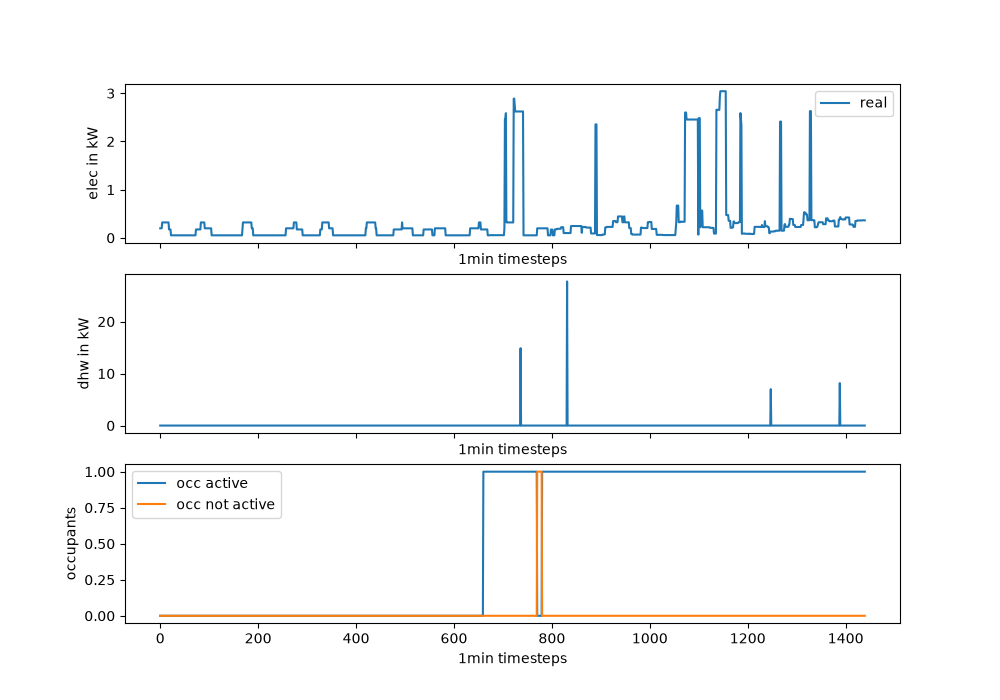

In [57]:
i =0
dyn = dyn.cpu()
mean_trgt = target_mean.numpy()
std_trgt  = target_std.numpy()
mean_cond = condition_mean.numpy()
std_cond  = condition_std.numpy()

occ = example["condition"][i] * std_cond + mean_cond
real = example["target"][i]* std_trgt + mean_trgt

occ_activ, occ_not_active = occ[0], occ[1]
elec_real, dhw_real = real[0], real[1]


fig, ax = plt.subplots(3,1, figsize=(10,7), sharex=True)


ax[0].plot(elec_real, label="real")
ax[0].set_ylabel("elec in kW")
ax[0].set_xlabel("1min timesteps")
ax[0].legend()

ax[1].plot(dhw_real, label="real")
ax[1].set_ylabel("dhw in kW")
ax[1].set_xlabel("1min timesteps")

ax[2].plot(occ_activ, label="occ active")
ax[2].plot(occ_not_active, label="occ not active")
ax[2].set_ylabel("occupants")
ax[2].set_xlabel("1min timesteps")
ax[2].legend()
plt.show()

In [47]:
#cond = build_condition(preprocessor, train_df,{"buildingType": "SFH", "sum_n_persons": 3, "future": False}, batch_size=32, device=device)

In [70]:
samples = sample1d(
    ema.ema_model,
    sequence_length=1440,
    batch_size=32,
    channels=2,
    static_cat=static_cat,
    static_cont=static_cont,
    static_bool=static_bool,
    dyn=dyn
)

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
i =8
final_samples = samples[-1]

trgt = trgt.cpu()
mean_trgt = target_mean.numpy()
std_trgt  = target_std.numpy()

gen  = final_samples[i] * std_trgt + mean_trgt
real = trgt[i]* std_trgt + mean_trgt

occ_act_gen, occ_n_act_gen = gen[0], gen[1]
occ_act_real, occ_n_real = real[0], real[1]


fig, ax = plt.subplots(2,1, figsize=(10,7), sharex=True)

ax[0].plot(occ_act_gen, label="generated")
ax[0].plot(occ_act_real, label="real")
ax[0].set_ylabel("occupancy active")
ax[0].set_xlabel("10 min timesteps")
ax[0].legend()

ax[1].plot( occ_n_act_gen, label="generated")
ax[1].plot(occ_n_real, label="real")
ax[1].set_ylabel("occupancy not active")
ax[1].set_xlabel("10 min timesteps")

plt.show()

C:\Users\Samuel\AppData\Local\Temp\ipykernel_24988\3371421613.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  occ = dyn[i] * std_cond + mean_cond
C:\Users\Samuel\AppData\Local\Temp\ipykernel_24988\3371421613.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  real = trgt[i]* std_trgt + mean_trgt


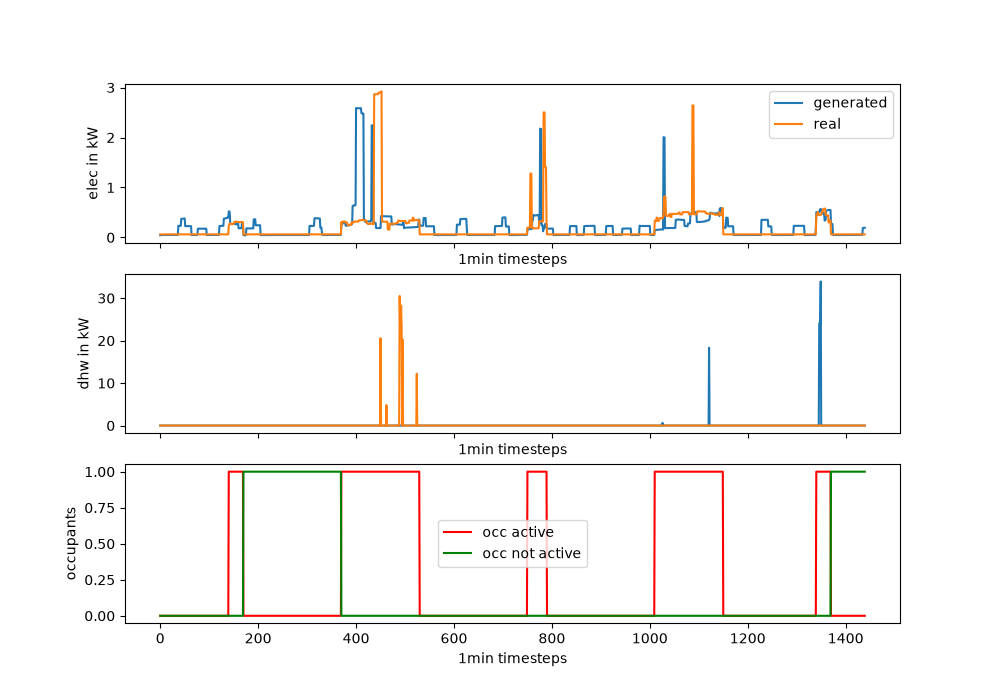

In [72]:
i =2
final_samples = samples[-1]
dyn = dyn.cpu()
trgt = trgt.cpu()
mean_trgt = target_mean.numpy()
std_trgt  = target_std.numpy()
mean_cond = condition_mean.numpy()
std_cond  = condition_std.numpy()

occ = dyn[i] * std_cond + mean_cond
gen  = final_samples[i] * std_trgt + mean_trgt
real = trgt[i]* std_trgt + mean_trgt



occ_activ, occ_not_active = occ[0], occ[1]
elec_gen, dhw_gen = gen[0], gen[1]
elec_real, dhw_real = real[0], real[1]


fig, ax = plt.subplots(3,1, figsize=(10,7), sharex=True)

ax[0].plot(elec_gen, label="generated")
ax[0].plot(elec_real, label="real")
ax[0].set_ylabel("elec in kW")
ax[0].set_xlabel("1min timesteps")
ax[0].legend()

ax[1].plot(dhw_gen, label="generated")
ax[1].plot(dhw_real, label="real")
ax[1].set_ylabel("dhw in kW")
ax[1].set_xlabel("1min timesteps")

ax[2].plot(occ_activ, label="occ active", color="r")
ax[2].plot(occ_not_active, label="occ not active", color="g")
ax[2].set_ylabel("occupants")
ax[2].set_xlabel("1min timesteps")
ax[2].legend()
plt.show()

In [ ]:
final_samples = samples[-1]
generated = final_samples[14, 0]
generated = (
    generated * target_std.item()
    + target_mean.item()
)

plt.figure(figsize=(12, 4))
plt.plot(generated)

plt.xlabel("1-minute interval")
plt.ylabel("DHW")
plt.title("Generated daily DHW profile")
print(generated.min())
plt.show()

In [ ]:
batch = example

In [ ]:
generated = final_samples[31, 0]

generated = (generated * target_std.item()+ target_mean.item())

real = batch["target"][1, 0]

real = (
    real * target_std.item()
    + target_mean.item()
)

plt.figure(figsize=(11, 4))
plt.plot(generated, label="generated")
plt.plot(real, label="real")
plt.legend()
plt.xlabel("1-minute interval")
plt.ylabel("Electricity")
plt.title("real daily electricity profile");

In [ ]:
#torch.save(ema.ema_model.state_dict(), "model_DHW_ema.pth")

In [ ]:
target_mean, target_std

In [ ]:
cond = build_condition(preprocessor, train_df,{"buildingType": "SFH", "sum_n_persons": 4, "future": True}, batch_size=32, device=device)

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Settings
# -----------------------
manifest_path = Path("../Ch_1_Data_Preparation/manifest.csv")
runs_dir = Path("../Ch_1_Data_Preparation/Generation/Generation/#Archiv")
HDF_KEY = "timeseries"
LOAD_COLUMN = "Electricity Load"
N_PER_TYPE = 300
RANDOM_SEED = 42

Manifest columns:
['Unnamed: 0', 'country', 'buildingType', 'surrounding', 'buildingAgeBin', 'a_ref', 'n_apartments', 'year_type', 'future', 'climateRegion', 'n_persons', 'freq', 'hasFirePlace', 'varyoccupancy', 'mean_load', 'nightReduction', 'capControl', 'occControl', 'comfortT_lb', 'comfortT_ub', 'cores', 'useCache', 'building_id', 'run_id', 'seed', 'sum_n_persons']

Runs in manifest per building type:
buildingType
MFH    4320
SFH    4320
TH     3960
AB     1800
Name: count, dtype: int64

Existing HDF5 files per building type:
buildingType
AB     361
SFH    303
Name: count, dtype: int64

Total existing files: 664 of 14400 manifest entries
AB: sampled 300 of 361 existing files
SFH: sampled 300 of 303 existing files

Final sampled files per building type:
buildingType
AB     300
SFH    300
Name: count, dtype: int64


0it [00:00, ?it/s]

0it [00:00, ?it/s]


Successfully read files:
AB: 300
SFH: 300

Number of successfully loaded timestep values per building type:
buildingType
AB     157680000
SFH    157680000
dtype: int64


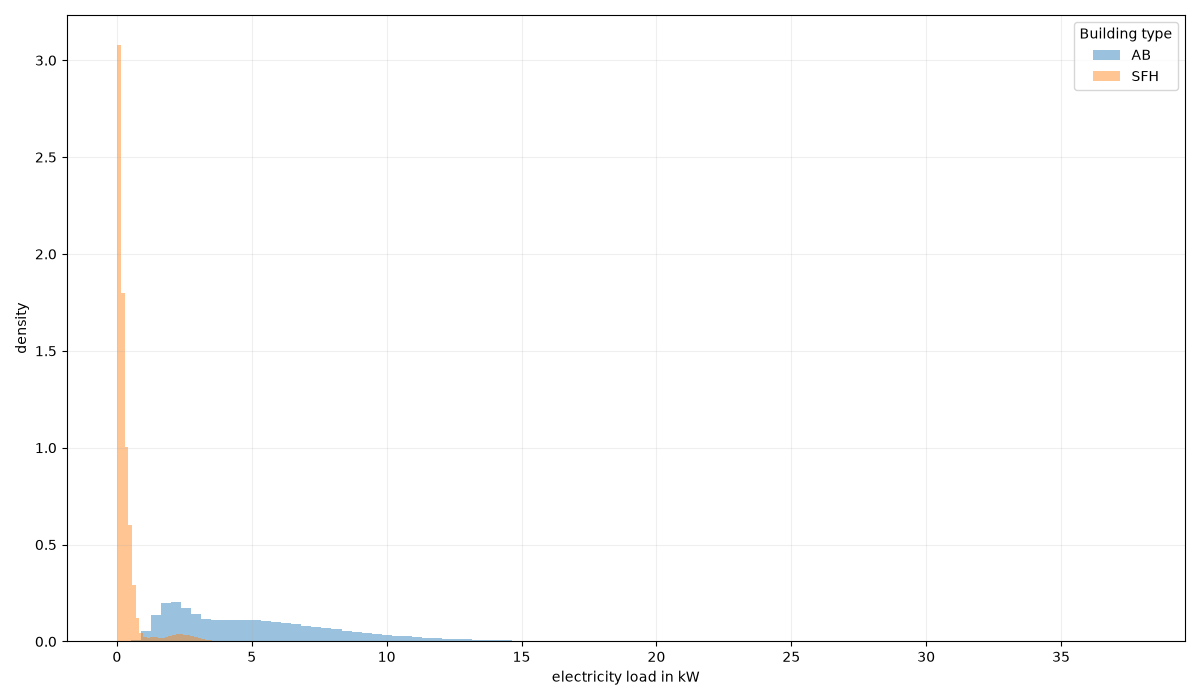

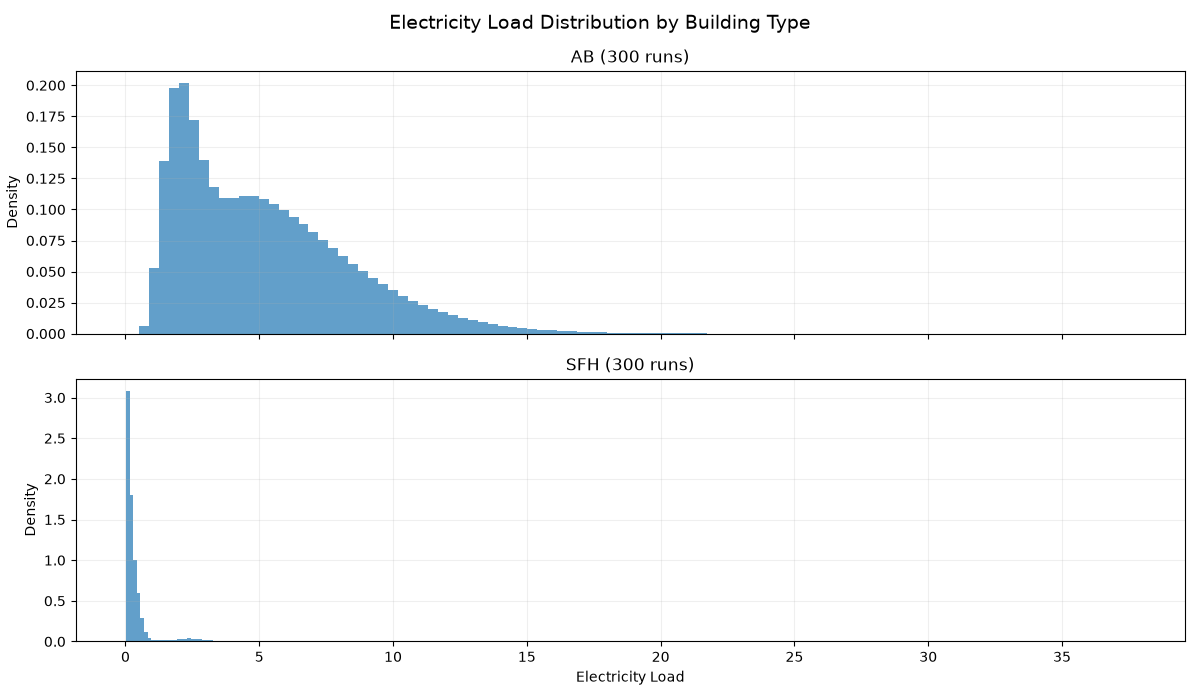


No sampled files were skipped during reading.


In [4]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# FILEPATH CONSTRUCTION
# ============================================================

def get_run_path(run_id):
    """
    Construct the expected HDF5 filepath from the run_id.

    Example:
        run_000001 -> C:/.../run_000001.h5

    Change this function if your files use a different
    filename or folder structure.
    """
    return runs_dir / f"{run_id}.h5"


# ============================================================
# READ MANIFEST
# ============================================================

manifest = pd.read_csv(manifest_path)

print("Manifest columns:")
print(manifest.columns.tolist())

print("\nRuns in manifest per building type:")
print(manifest["buildingType"].value_counts())


# ============================================================
# BUILD FILEPATHS AND CHECK WHICH FILES EXIST
# ============================================================

manifest["filepath"] = manifest["run_id"].apply(get_run_path)

manifest["exists"] = manifest["filepath"].apply(Path.exists)

available = manifest.loc[manifest["exists"]].copy()

print("\nExisting HDF5 files per building type:")
print(available["buildingType"].value_counts())

print(
    f"\nTotal existing files: {len(available)} "
    f"of {len(manifest)} manifest entries"
)


# ============================================================
# SAMPLE UP TO 300 EXISTING FILES PER BUILDING TYPE
# ============================================================

sampled_parts = []

for building_type, group in available.groupby("buildingType"):

    n_to_sample = min(N_PER_TYPE, len(group))

    sampled_group = group.sample(
        n=n_to_sample,
        random_state=RANDOM_SEED
    )

    sampled_parts.append(sampled_group)

    print(
        f"{building_type}: sampled "
        f"{n_to_sample} of {len(group)} existing files"
    )


if not sampled_parts:
    raise RuntimeError(
        "No existing HDF5 files were found. "
        "Check runs_dir and get_run_path()."
    )


sampled = pd.concat(
    sampled_parts,
    ignore_index=True
)

print("\nFinal sampled files per building type:")
print(sampled["buildingType"].value_counts())


# ============================================================
# READ ELECTRICITY LOAD FROM HDF5 FILES
# ============================================================

load_data = []

success_counts = {}
failed_files = []

for building_type, group in sampled.groupby("buildingType"):

    success_counts[building_type] = 0

    for _, row in tqdm(group.iterrows()):

        filepath = row["filepath"]
        run_id = row["run_id"]

        try:
            ts = pd.read_hdf(
                filepath,
                key=HDF_KEY
            )

            # Check whether the required column exists
            if LOAD_COLUMN not in ts.columns:
                print(
                    f"Skipping {filepath.name}: "
                    f"column '{LOAD_COLUMN}' not found."
                )

                failed_files.append(
                    {
                        "run_id": run_id,
                        "filepath": filepath,
                        "reason": "Load column missing"
                    }
                )

                continue

            # Keep only valid load values
            loads = (
                pd.to_numeric(
                    ts[LOAD_COLUMN],
                    errors="coerce"
                )
                .dropna()
            )

            if loads.empty:
                print(
                    f"Skipping {filepath.name}: "
                    "no valid load values."
                )

                failed_files.append(
                    {
                        "run_id": run_id,
                        "filepath": filepath,
                        "reason": "No valid load values"
                    }
                )

                continue

            load_data.append(
                pd.DataFrame(
                    {
                        "Electricity Load": loads.to_numpy(),
                        "buildingType": building_type,
                        "run_id": run_id
                    }
                )
            )

            success_counts[building_type] += 1

        except FileNotFoundError:
            # Should normally already be filtered out above,
            # but this makes the loop robust if a file disappears.
            print(
                f"Skipping missing file: {filepath}"
            )

            failed_files.append(
                {
                    "run_id": run_id,
                    "filepath": filepath,
                    "reason": "File not found"
                }
            )

        except (KeyError, OSError, ValueError) as e:
            print(
                f"Skipping {filepath.name}: {e}"
            )

            failed_files.append(
                {
                    "run_id": run_id,
                    "filepath": filepath,
                    "reason": str(e)
                }
            )


# ============================================================
# COMBINE ALL LOAD DATA
# ============================================================

if not load_data:
    raise RuntimeError(
        "No valid Electricity Load data could be read "
        "from the sampled HDF5 files."
    )


loads = pd.concat(
    load_data,
    ignore_index=True
)


print("\nSuccessfully read files:")
for building_type, count in success_counts.items():
    print(f"{building_type}: {count}")


print(
    "\nNumber of successfully loaded timestep values "
    "per building type:"
)

print(
    loads.groupby("buildingType")
    .size()
)


# ============================================================
# PLOT OVERLAID HISTOGRAMS
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 7)
)

for building_type, group in loads.groupby("buildingType"):

    ax.hist(
        group["Electricity Load"],
        bins=100,
        alpha=0.45,
        density=True,
        label=building_type
    )


ax.set_xlabel("electricity load in kW")
ax.set_ylabel("density")


ax.legend(
    title="Building type"
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()
fig.savefig(
    "electricity_load_histogram.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ============================================================
# OPTIONAL: ONE HISTOGRAM PER BUILDING TYPE
# ============================================================

building_types = sorted(
    loads["buildingType"].unique()
)

fig, axes = plt.subplots(
    nrows=len(building_types),
    ncols=1,
    figsize=(12, 3.5 * len(building_types)),
    sharex=True
)

# If there is only one building type,
# matplotlib does not return an array
if len(building_types) == 1:
    axes = [axes]


for ax, building_type in zip(
    axes,
    building_types
):

    group = loads.loc[
        loads["buildingType"] == building_type,
        "Electricity Load"
    ]

    ax.hist(
        group,
        bins=100,
        density=True,
        alpha=0.7
    )

    ax.set_title(
        f"{building_type} "
        f"({success_counts.get(building_type, 0)} runs)"
    )

    ax.set_ylabel("Density")

    ax.grid(
        alpha=0.2
    )


axes[-1].set_xlabel(
    "Electricity Load"
)

fig.suptitle(
    "Electricity Load Distribution by Building Type",
    fontsize=14
)

plt.tight_layout()
plt.show()


# ============================================================
# OPTIONAL: SHOW FAILED FILES
# ============================================================

if failed_files:

    failed_df = pd.DataFrame(
        failed_files
    )

    print("\nFiles skipped while reading:")
    print(failed_df)

else:
    print(
        "\nNo sampled files were skipped during reading."
    )

In [ ]:
sampled

In [ ]:
bs_res = pd.read_parquet(r"C:\Users\Samuel\Sciebo\Documents\timeseries_summary.parquet")

In [ ]:
bs_res